
# Exercise 03 — Spatial Analysis of Maryland Eviction Warrants

**Name:** Emmanuel Opoku-Boateng  
**Course:** URSP688Y Urban Data Science & Smart Cities  
**Instructor:** Chester Harvey



## Abstract

This study asks whether eviction warrants in Maryland were spatially concentrated in census tracts with higher renter shares and higher poverty levels between 2022 and 2024. To answer this question, I geocoded address-level eviction warrant records using the U.S. Census batch geocoder, retained records with usable spatial coordinates, and spatially joined those points to Maryland census tracts. I then merged tract geometries with 2023 ACS 5-year tract-level indicators from the U.S. Census Bureau, including renter-occupied households and poverty counts. Using these data, I calculated tract-level eviction warrant totals and standardized them as warrants per 100 renter households. I compared these rates across tracts, mapped their spatial distribution, and examined how they varied with tract poverty and renter concentration.

## Research question

**Are eviction warrants in Maryland disproportionately concentrated in census tracts with higher poverty rates and larger renter populations?**

In [41]:

import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import requests
from pathlib import Path

import utils
import exercise03
import census_geocode

%load_ext autoreload
%autoreload 2

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload



## 1. Loading the eviction warrant data


In [ ]:
# Load the eviction warrant data
eviction_file = [
    Path('md_eviction_warrants_through_sept2025.csv'),
]

csv_path = next((p for p in eviction_file if p.exists()), None)

print(f'Using file: {csv_path.name}')

# Read the CSV into a dataframe called warrants_df 
warrants_df = pd.read_csv(csv_path, low_memory=False)

# Clean TenantZipCode: convert to numeric, allow missing values and store as text
warrants_df['TenantZipCode'] = pd.to_numeric(warrants_df['TenantZipCode'], errors='coerce').astype('Int64').astype('string')
for col in ['EventDate', 'EvictedDate', 'SourceDate']:
    if col in warrants_df.columns:
        warrants_df[col] = pd.to_datetime(warrants_df[col], errors='coerce')

# Filter to analysis window (through end of 2024)
if 'EventDate' in warrants_df.columns:
    warrants_df = warrants_df[warrants_df['EventDate'] <= '2024-12-31'].copy()

# Quick look at the data
print(f'Total warrant records in analysis window: {len(warrants_df):,}')
warrants_df.head()


Using file: md_eviction_warrants_through_sept2025.csv
Total warrant records in analysis window: 411,038


,Unnamed: 0,ID,EventDate,EventType,EventComment,County,Location,TenantAddress,TenantCity,TenantState,TenantZipCode,CaseType,CaseNumber,EvictedDate,Source,SourceDate,Year,EvictionYear
196841,196841,NaN,2024-12-31,Petition - For Warrant of Restitution Filed,EWRIT::Warrant of Restitution,Baltimore,Essex,9100 Oswald Way APT 3C,Baltimore,MD,21237,Failure to Pay Rent,D-08-LT-24-40214-057,NaT,12/2024 - Petition - For Warrant of Restitutio...,2025-01-25,2024.0,NaN
196842,196842,NaN,2024-12-31,Petition - For Warrant of Restitution Filed,EWRIT::Warrant of Restitution,Baltimore,Essex,9204 Oswald Court APT 2B,Baltimore,MD,21237,Failure to Pay Rent,D-08-LT-24-40214-046,NaT,12/2024 - Petition - For Warrant of Restitutio...,2025-01-25,2024.0,NaN
196843,196843,NaN,2024-12-31,Petition - For Warrant of Restitution Filed,EWRIT::Warrant of Restitution,Baltimore,Essex,9212 Oswald Court APT 1D,Baltimore,MD,21237,Failure to Pay Rent,D-08-LT-24-40214-053,NaT,12/2024 - Petition - For Warrant of Restitutio...,2025-01-25,2024.0,NaN
196844,196844,NaN,2024-12-31,Petition - For Warrant of Restitution Filed,EWRIT::Warrant of Restitution,Baltimore,Essex,9202 Oswald Court APT 2D,Baltimore,MD,21237,Failure to Pay Rent,D-08-LT-24-40214-043,NaT,12/2024 - Petition - For Warrant of Restitutio...,2025-01-25,2024.0,NaN
196845,196845,NaN,2024-12-31,Petition - For Warrant of Restitution Filed,EWRIT::Warrant of Restitution,Baltimore,Essex,9102 Oswald Way APT 1D,Baltimore,MD,21237,Failure to Pay Rent,D-08-LT-24-40214-059,NaT,12/2024 - Petition - For Warrant of Restitutio...,2025-01-25,2024.0,NaN



## 2. Preparing unique addresses for batch geocoding

The Census batch geocoder accepts at most 10,000 rows per file, so the workflow is:
1. reduce to unique tenant addresses,
2. split them into chunks,
3. geocode each chunk,
4. recombine the outputs, and
5. merge the coordinates back to the full warrant records.


In [ ]:
# Prepare warrants for geocoding. Send it to the helper function that: keeps only the address columns needed for geocoding, removes duplicate addresses, resets the index, repares a clean geocoding input table and Store the result as geocode_input_df
geocode_input_df = exercise03.prep_warrants_for_geocoding(warrants_df)
geocode_input_df.head()


411038 warrants input
Reduced to 167947 unique addresses


,TenantAddress,TenantCity,TenantState,TenantZipCode
0,9100 Oswald Way APT 3C,Baltimore,MD,21237
1,9204 Oswald Court APT 2B,Baltimore,MD,21237
2,9212 Oswald Court APT 1D,Baltimore,MD,21237
3,9202 Oswald Court APT 2D,Baltimore,MD,21237
4,9102 Oswald Way APT 1D,Baltimore,MD,21237


In [ ]:
# Split geocode_input_df into chunks of 9999 rows and save each chunk as a separate CSV file in a directory called geocode_inputs/. Include the header in the first file only, and do not include the index in any of the files. Print out how many chunk files were saved.
geocode_input_dfs = utils.chunk_dataframe(geocode_input_df, 9999)
utils.save_dfs_to_csv(geocode_input_dfs, 'geocode_inputs', header=False)
print(f'Saved {len(geocode_input_dfs)} chunk files to geocode_inputs/')


split dataframe into 17 chunks
Saved 17 chunk files to geocode_inputs/



## 3. Running the Census batch geocoder

In [ ]:
# Set this to True to run the geocoder and create new geocode_outputs (which will overwrite any existing files in that directory). Set to False to skip API calls and use existing geocode_outputs if they exist.
RUN_GEOCODER = False    # set to False to skip API calls and use existing geocode_outputs if they exist. Set to True to run the geocoder and create new geocode_outputs (which will overwrite any existing files in that directory).
TEST_MODE = False   # set to True to geocode only the first chunk while debugging

if RUN_GEOCODER:
    census_geocode.geocode_csvs('geocode_inputs', 'geocode_outputs', test=TEST_MODE)
else:
    print('Skipping API calls. Set RUN_GEOCODER = True to geocode addresses.')


Processing file: geocode_inputs\df_0.csv
    Already processed
Processing file: geocode_inputs\df_1.csv
    Already processed
Processing file: geocode_inputs\df_10.csv
    Already processed
Processing file: geocode_inputs\df_11.csv
    Already processed
Processing file: geocode_inputs\df_12.csv
    Already processed
Processing file: geocode_inputs\df_13.csv
    Already processed
Processing file: geocode_inputs\df_14.csv
    Already processed
Processing file: geocode_inputs\df_15.csv
    Already processed
Processing file: geocode_inputs\df_16.csv
    Already processed
Processing file: geocode_inputs\df_2.csv
    Already processed
Processing file: geocode_inputs\df_3.csv
    Already processed
Processing file: geocode_inputs\df_4.csv
    Already processed
Processing file: geocode_inputs\df_5.csv
    Already processed
Processing file: geocode_inputs\df_6.csv
    Already processed
Processing file: geocode_inputs\df_7.csv
    Already processed
Processing file: geocode_inputs\df_8.csv
    Alr

In [ ]:
# Combine the geocode output CSVs into a single dataframe called geocode_output_df. Print out how many rows were returned by the geocoder and show the first few rows of the combined geocode output.
geocode_output_df = exercise03.combine_census_geocoded_csvs('geocode_outputs')
print(f'Rows returned by geocoder: {len(geocode_output_df):,}')
geocode_output_df.head()


Rows returned by geocoder: 167,947


,unique_id,input_address,match_status,match_type,match_address,match_lon_lat,match_tiger_line_id,match_tiger_line_side
0,4970,"3114 Bancroft Road APT C, Baltimore, MD, 21215",Match,Non_Exact,"3114 BANCROFT RD, BALTIMORE, MD, 21215","-76.694807284962,39.367247977466",657038025.0,R
1,3640,"6551 Hil Mar Drive APT 403, District Heights, ...",Match,Exact,"6551 HIL MAR DR, DISTRICT HEIGHTS, MD, 20747","-76.894930049568,38.843185255742",76318618.0,R
2,4971,"3314 Clarks Lane APT D, Baltimore, MD, 21215",Match,Non_Exact,"3314 CLARKS LN, BALTIMORE, MD, 21215","-76.69539968133,39.367249176244",657045671.0,R
3,2306,"417 A LINCOLN DRIVE, GLEN BURNIE, MD, 21060",Match,Non_Exact,"417 LINCOLN DR, GLEN BURNIE, MD, 21060","-76.577562578032,39.14896501422",657675270.0,R
4,3638,"6573 Hil Mar Drive APT 301, District Heights, ...",Match,Exact,"6573 HIL MAR DR, DISTRICT HEIGHTS, MD, 20747","-76.894814986842,38.843202593959",76318618.0,R


In [ ]:
# Merge output rows back to unique address inputs by row order
geocoded_df = geocode_input_df.merge(geocode_output_df, left_index=True, right_index=True)

# Merge geocodes back to the full warrant records
warrants_df = warrants_df.merge(
    geocoded_df,
    on=['TenantAddress', 'TenantCity', 'TenantState', 'TenantZipCode'],
    how='left'
)

print(f'Full warrant records after merging geocodes: {len(warrants_df):,}')
warrants_df.head()


Full warrant records after merging geocodes: 411,038


,Unnamed: 0,ID,EventDate,EventType,EventComment,County,Location,TenantAddress,TenantCity,TenantState,TenantZipCode,CaseType,CaseNumber,EvictedDate,Source,SourceDate,Year,EvictionYear,unique_id,input_address,match_status,match_type,match_address,match_lon_lat,match_tiger_line_id,match_tiger_line_side
0,196841,NaN,2024-12-31,Petition - For Warrant of Restitution Filed,EWRIT::Warrant of Restitution,Baltimore,Essex,9100 Oswald Way APT 3C,Baltimore,MD,21237,Failure to Pay Rent,D-08-LT-24-40214-057,NaT,12/2024 - Petition - For Warrant of Restitutio...,2025-01-25,2024.0,NaN,4970,"3114 Bancroft Road APT C, Baltimore, MD, 21215",Match,Non_Exact,"3114 BANCROFT RD, BALTIMORE, MD, 21215","-76.694807284962,39.367247977466",657038025.0,R
1,196842,NaN,2024-12-31,Petition - For Warrant of Restitution Filed,EWRIT::Warrant of Restitution,Baltimore,Essex,9204 Oswald Court APT 2B,Baltimore,MD,21237,Failure to Pay Rent,D-08-LT-24-40214-046,NaT,12/2024 - Petition - For Warrant of Restitutio...,2025-01-25,2024.0,NaN,3640,"6551 Hil Mar Drive APT 403, District Heights, ...",Match,Exact,"6551 HIL MAR DR, DISTRICT HEIGHTS, MD, 20747","-76.894930049568,38.843185255742",76318618.0,R
2,196843,NaN,2024-12-31,Petition - For Warrant of Restitution Filed,EWRIT::Warrant of Restitution,Baltimore,Essex,9212 Oswald Court APT 1D,Baltimore,MD,21237,Failure to Pay Rent,D-08-LT-24-40214-053,NaT,12/2024 - Petition - For Warrant of Restitutio...,2025-01-25,2024.0,NaN,4971,"3314 Clarks Lane APT D, Baltimore, MD, 21215",Match,Non_Exact,"3314 CLARKS LN, BALTIMORE, MD, 21215","-76.69539968133,39.367249176244",657045671.0,R
3,196844,NaN,2024-12-31,Petition - For Warrant of Restitution Filed,EWRIT::Warrant of Restitution,Baltimore,Essex,9202 Oswald Court APT 2D,Baltimore,MD,21237,Failure to Pay Rent,D-08-LT-24-40214-043,NaT,12/2024 - Petition - For Warrant of Restitutio...,2025-01-25,2024.0,NaN,2306,"417 A LINCOLN DRIVE, GLEN BURNIE, MD, 21060",Match,Non_Exact,"417 LINCOLN DR, GLEN BURNIE, MD, 21060","-76.577562578032,39.14896501422",657675270.0,R
4,196845,NaN,2024-12-31,Petition - For Warrant of Restitution Filed,EWRIT::Warrant of Restitution,Baltimore,Essex,9102 Oswald Way APT 1D,Baltimore,MD,21237,Failure to Pay Rent,D-08-LT-24-40214-059,NaT,12/2024 - Petition - For Warrant of Restitutio...,2025-01-25,2024.0,NaN,3638,"6573 Hil Mar Drive APT 301, District Heights, ...",Match,Exact,"6573 HIL MAR DR, DISTRICT HEIGHTS, MD, 20747","-76.894814986842,38.843202593959",76318618.0,R


In [ ]:
# Convert the geocoded warrants to a GeoDataFrame called warrants_gdf, using the helper function lonlat_str_to_geodataframe. Print out the CRS of the resulting GeoDataFrame and show the first few rows.
warrants_gdf = utils.lonlat_str_to_geodataframe(warrants_df, 'match_lon_lat')
print(warrants_gdf.crs)
warrants_gdf.head()


EPSG:4326


,Unnamed: 0,ID,EventDate,EventType,EventComment,County,Location,TenantAddress,TenantCity,TenantState,TenantZipCode,CaseType,CaseNumber,EvictedDate,Source,SourceDate,Year,EvictionYear,unique_id,input_address,match_status,match_type,match_address,match_lon_lat,match_tiger_line_id,match_tiger_line_side,lon,lat,geometry
0,196841,NaN,2024-12-31,Petition - For Warrant of Restitution Filed,EWRIT::Warrant of Restitution,Baltimore,Essex,9100 Oswald Way APT 3C,Baltimore,MD,21237,Failure to Pay Rent,D-08-LT-24-40214-057,NaT,12/2024 - Petition - For Warrant of Restitutio...,2025-01-25,2024.0,NaN,4970,"3114 Bancroft Road APT C, Baltimore, MD, 21215",Match,Non_Exact,"3114 BANCROFT RD, BALTIMORE, MD, 21215","-76.694807284962,39.367247977466",657038025.0,R,-76.694807284962,39.367247977466,POINT (-76.69481 39.36725)
1,196842,NaN,2024-12-31,Petition - For Warrant of Restitution Filed,EWRIT::Warrant of Restitution,Baltimore,Essex,9204 Oswald Court APT 2B,Baltimore,MD,21237,Failure to Pay Rent,D-08-LT-24-40214-046,NaT,12/2024 - Petition - For Warrant of Restitutio...,2025-01-25,2024.0,NaN,3640,"6551 Hil Mar Drive APT 403, District Heights, ...",Match,Exact,"6551 HIL MAR DR, DISTRICT HEIGHTS, MD, 20747","-76.894930049568,38.843185255742",76318618.0,R,-76.894930049568,38.843185255742,POINT (-76.89493 38.84319)
2,196843,NaN,2024-12-31,Petition - For Warrant of Restitution Filed,EWRIT::Warrant of Restitution,Baltimore,Essex,9212 Oswald Court APT 1D,Baltimore,MD,21237,Failure to Pay Rent,D-08-LT-24-40214-053,NaT,12/2024 - Petition - For Warrant of Restitutio...,2025-01-25,2024.0,NaN,4971,"3314 Clarks Lane APT D, Baltimore, MD, 21215",Match,Non_Exact,"3314 CLARKS LN, BALTIMORE, MD, 21215","-76.69539968133,39.367249176244",657045671.0,R,-76.69539968133,39.367249176244,POINT (-76.6954 39.36725)
3,196844,NaN,2024-12-31,Petition - For Warrant of Restitution Filed,EWRIT::Warrant of Restitution,Baltimore,Essex,9202 Oswald Court APT 2D,Baltimore,MD,21237,Failure to Pay Rent,D-08-LT-24-40214-043,NaT,12/2024 - Petition - For Warrant of Restitutio...,2025-01-25,2024.0,NaN,2306,"417 A LINCOLN DRIVE, GLEN BURNIE, MD, 21060",Match,Non_Exact,"417 LINCOLN DR, GLEN BURNIE, MD, 21060","-76.577562578032,39.14896501422",657675270.0,R,-76.577562578032,39.14896501422,POINT (-76.57756 39.14897)
4,196845,NaN,2024-12-31,Petition - For Warrant of Restitution Filed,EWRIT::Warrant of Restitution,Baltimore,Essex,9102 Oswald Way APT 1D,Baltimore,MD,21237,Failure to Pay Rent,D-08-LT-24-40214-059,NaT,12/2024 - Petition - For Warrant of Restitutio...,2025-01-25,2024.0,NaN,3638,"6573 Hil Mar Drive APT 301, District Heights, ...",Match,Exact,"6573 HIL MAR DR, DISTRICT HEIGHTS, MD, 20747","-76.894814986842,38.843202593959",76318618.0,R,-76.894814986842,38.843202593959,POINT (-76.89481 38.8432)



## 4. Evaluating geocoding quality


In [ ]:
# Calculate the share of all warrants that have geocoded coordinates (geom_rate) and the share of all warrants that have an exact geocode match with coordinates (exact_rate). 
# Store these two metrics in a Series called quality_summary with index values 'has_coordinates_share' and 'exact_match_share', respectively. 
# Also include the total number of warrants in the summary under the index 'total_warrants'. Display the quality_summary.
geom_rate = warrants_gdf['match_lon_lat'].notna().mean()
exact_rate = ((warrants_gdf['match_type'] == 'Exact') & warrants_gdf['match_lon_lat'].notna()).mean()

quality_summary = pd.Series({
    'total_warrants': len(warrants_gdf),
    'has_coordinates_share': geom_rate,
    'exact_match_share': exact_rate,
}).to_frame('value')
quality_summary


,value
total_warrants,411038.000000
has_coordinates_share,0.950109
exact_match_share,0.545142


In [ ]:
# For the tract-level analysis, we will keep only the warrants that have an exact geocode match with coordinates. 
# Create a new GeoDataFrame called analysis_points that filters warrants_gdf to only include rows where 'match_lon_lat' is not null and 'match_type' is 'Exact'. 
# Print out how many exact geocoded warrants are included in the analysis_points GeoDataFrame.
analysis_points = warrants_gdf[
    warrants_gdf['match_lon_lat'].notna() & warrants_gdf['match_type'].eq('Exact')
].copy()

print(f'Exact geocoded warrants used for tract analysis: {len(analysis_points):,}')


Exact geocoded warrants used for tract analysis: 224,074



## 5. Load Maryland census tracts and 2023 ACS tract data

I use:
- **2023 TIGER/Line census tract geometries** for Maryland
- **2023 ACS 5-year estimates** for renter households and poverty

Variables pulled from ACS:
- `B25003_001E`: occupied housing units
- `B25003_003E`: renter-occupied housing units
- `B17001_001E`: population for whom poverty status is determined
- `B17001_002E`: population below poverty level


In [ ]:
# Show the column names of the tracts GeoDataFrame.
tracts.columns.tolist()

['STATEFP',
 'COUNTYFP',
 'TRACTCE',
 'GEOID',
 'GEOIDFQ',
 'NAME_x',
 'NAMELSAD',
 'MTFCC',
 'FUNCSTAT',
 'ALAND',
 'AWATER',
 'INTPTLAT',
 'INTPTLON',
 'geometry',
 'NAME_y',
 'B25003_001E',
 'B25003_003E',
 'B17001_001E',
 'B17001_002E',
 'pct_renter',
 'pct_poverty']

In [ ]:
# Load the census tracts for Maryland directly from the Census TIGERweb URL as a GeoDataFrame called tracts. 
# Convert the CRS to 3857 for easier plotting and spatial analysis.
tracts_url = 'https://www2.census.gov/geo/tiger/TIGER2023/TRACT/tl_2023_24_tract.zip'
tracts = gpd.read_file(tracts_url)
tracts = tracts.to_crs(3857)

acs_url = 'https://api.census.gov/data/2023/acs/acs5'
acs_params = {
    'get': 'NAME,B25003_001E,B25003_003E,B17001_001E,B17001_002E',
    'for': 'tract:*',
    'in': 'state:24 county:*'
}
acs_resp = requests.get(acs_url, params=acs_params, timeout=60)
acs_resp.raise_for_status()
acs_json = acs_resp.json()

# Convert the ACS response to a DataFrame called acs
acs = pd.DataFrame(acs_json[1:], columns=acs_json[0])
value_cols = ['B25003_001E', 'B25003_003E', 'B17001_001E', 'B17001_002E']
for c in value_cols:
    acs[c] = pd.to_numeric(acs[c], errors='coerce')

# Create a GEOID column in acs by concatenating the state, county, and tract codes. 
# Then calculate the percentage of renter-occupied housing units (pct_renter) and the percentage of people in poverty (pct_poverty) for each tract. 
# Store these as new columns in the acs DataFrame.
acs['GEOID'] = acs['state'] + acs['county'] + acs['tract']
acs['pct_renter'] = 100 * acs['B25003_003E'] / acs['B25003_001E']
acs['pct_poverty'] = 100 * acs['B17001_002E'] / acs['B17001_001E']

# Merge the ACS data to the tracts GeoDataFrame using the GEOID column. 
# Keep only the GEOID, NAMELSAD, pct_renter and pct_poverty columns from the tracts GeoDataFrame.
tracts = tracts.merge(
    acs[['GEOID', 'B25003_001E', 'B25003_003E', 'B17001_001E', 'B17001_002E', 'pct_renter', 'pct_poverty']],
    on='GEOID',
    how='left'
)

tracts[['GEOID', 'NAMELSAD', 'pct_renter', 'pct_poverty']].head()


,GEOID,NAMELSAD,pct_renter,pct_poverty
0,24005403100,Census Tract 4031,25.593009,4.626168
1,24005403201,Census Tract 4032.01,6.026963,4.581498
2,24033807304,Census Tract 8073.04,16.149068,8.647343
3,24033807305,Census Tract 8073.05,39.634146,19.833637
4,24033807405,Census Tract 8074.05,44.535783,8.492075



## 6. Spatially joining eviction points to census tracts


In [ ]:

analysis_points = analysis_points.to_crs(tracts.crs)
points_with_tracts = gpd.sjoin(
    analysis_points,
    tracts[['GEOID', 'NAME', 'pct_renter', 'pct_poverty', 'geometry']],
    how='left',
    predicate='within'
)

print(f'Points successfully assigned to tracts: {points_with_tracts["GEOID"].notna().sum():,}')
points_with_tracts[['TenantAddress', 'TenantCity', 'GEOID', 'NAME']].head()


Points successfully assigned to tracts: 224,049


,TenantAddress,TenantCity,GEOID,NAME
1,9204 Oswald Court APT 2B,Baltimore,24033802106,8021.06
4,9102 Oswald Way APT 1D,Baltimore,24033802106,8021.06
7,11 Paula Place APT 1A,Baltimore,24033802106,8021.06
9,1 Paula Place APT 3D,Baltimore,24043010700,107
10,9 Paula Place APT 1C,Baltimore,24043010700,107


In [ ]:
# Count the number of warrants for each tract
tract_counts = (
    points_with_tracts.dropna(subset=['GEOID'])
    .groupby('GEOID')
    .size()
    .rename('warrant_count')
    .reset_index()
)

# Count the number of warrants for each tract and year
tract_year_counts = (
    points_with_tracts.dropna(subset=['GEOID'])
    .assign(year=points_with_tracts['EventDate'].dt.year)
    .groupby(['GEOID', 'year'])
    .size()
    .rename('count')
    .reset_index()
)

# Merge the tract-level warrant counts back to the tracts GeoDataFrame. 
# Fill any missing warrant counts with 0. 
# Then calculate the number of warrants per 100 renter-occupied households for each tract and store it in a new column called warrants_per_100_renter_hh.
tract_summary = tracts.merge(tract_counts, on='GEOID', how='left')
tract_summary['warrant_count'] = tract_summary['warrant_count'].fillna(0)
tract_summary['warrants_per_100_renter_hh'] = np.where(
    tract_summary['B25003_003E'] > 0,
    100 * tract_summary['warrant_count'] / tract_summary['B25003_003E'],
    np.nan
)

tract_summary[['GEOID', 'NAME', 'warrant_count', 'warrants_per_100_renter_hh', 'pct_renter', 'pct_poverty']].head()


,GEOID,NAME,warrant_count,warrants_per_100_renter_hh,pct_renter,pct_poverty
0,24005403100,4031,2.0,0.975610,25.593009,4.626168
1,24005403201,4032.01,22.0,28.947368,6.026963,4.581498
2,24033807304,8073.04,14.0,13.461538,16.149068,8.647343
3,24033807305,8073.05,197.0,43.296703,39.634146,19.833637
4,24033807405,8074.05,75.0,8.143322,44.535783,8.492075



## 7. Descriptive results


In [ ]:
# Create a summary table as a Series called summary_table that includes the following metrics:  
summary_table = pd.Series({
    'tracts_in_md': len(tract_summary),
    'tracts_with_at_least_1_warrant': int((tract_summary['warrant_count'] > 0).sum()),
    'total_exact_geocoded_warrants_joined': int(tract_summary['warrant_count'].sum()),
    'mean_warrants_per_100_renter_hh': tract_summary['warrants_per_100_renter_hh'].mean(),
    'median_warrants_per_100_renter_hh': tract_summary['warrants_per_100_renter_hh'].median(),
}).to_frame('value')
summary_table


,value
tracts_in_md,1475.000000
tracts_with_at_least_1_warrant,1386.000000
total_exact_geocoded_warrants_joined,224049.000000
mean_warrants_per_100_renter_hh,24.916917
median_warrants_per_100_renter_hh,14.084017


In [ ]:
# Identify the top 15 tracts with the highest number of warrants per 100 renter-occupied households.
top_tracts = tract_summary.sort_values('warrants_per_100_renter_hh', ascending=False)[
    ['NAME', 'warrant_count', 'warrants_per_100_renter_hh', 'pct_renter', 'pct_poverty']
].head(15)

top_tracts


,NAME,warrant_count,warrants_per_100_renter_hh,pct_renter,pct_poverty
123,7001.01,3.0,300.000000,0.063331,4.901541
614,8004.11,615.0,246.000000,16.600266,6.650191
878,8021.06,2870.0,234.477124,65.700483,17.695214
1276,8010.03,73.0,182.500000,1.765225,9.014479
1444,8025.01,1451.0,180.922693,62.218774,22.679153
1072,4518.01,1083.0,177.540984,32.156036,14.211695
341,2801.01,712.0,171.980676,35.782195,9.702035
1417,8018.01,903.0,160.106383,65.734266,21.379648
729,4926,1032.0,159.259259,42.885506,6.584022
748,7508.04,340.0,158.139535,14.154049,1.475212


In [ ]:
# Calculate the correlation between warrants_per_100_renter_hh, pct_renter and pct_poverty across all tracts.
valid = tract_summary[['warrants_per_100_renter_hh', 'pct_renter', 'pct_poverty']].dropna()
correlations = valid.corr(numeric_only=True)
correlations


,warrants_per_100_renter_hh,pct_renter,pct_poverty
warrants_per_100_renter_hh,1.000000,0.273692,0.332161
pct_renter,0.273692,1.000000,0.577887
pct_poverty,0.332161,0.577887,1.000000


In [ ]:
# Create a new column in tract_summary called poverty_quintile that categorizes tracts into quintiles based on the pct_poverty column.
tract_summary['poverty_quintile'] = pd.qcut(
    tract_summary['pct_poverty'],
    5,
    labels=['Q1 lowest poverty', 'Q2', 'Q3', 'Q4', 'Q5 highest poverty'],
    duplicates='drop'
)

quintile_summary = tract_summary.groupby('poverty_quintile', observed=False).agg(
    mean_warrant_rate=('warrants_per_100_renter_hh', 'mean'),
    median_warrant_rate=('warrants_per_100_renter_hh', 'median'),
    tract_count=('GEOID', 'count')
)

quintile_summary


,mean_warrant_rate,median_warrant_rate,tract_count
poverty_quintile,,,
Q1 lowest poverty,11.807634,5.633803,292
Q2,17.971484,9.976976,291
Q3,23.663179,12.244898,291
Q4,28.968486,18.593449,291
Q5 highest poverty,42.185411,34.474339,291



## 8. Visualization


c:\Users\boatf\miniconda3\envs\688y\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


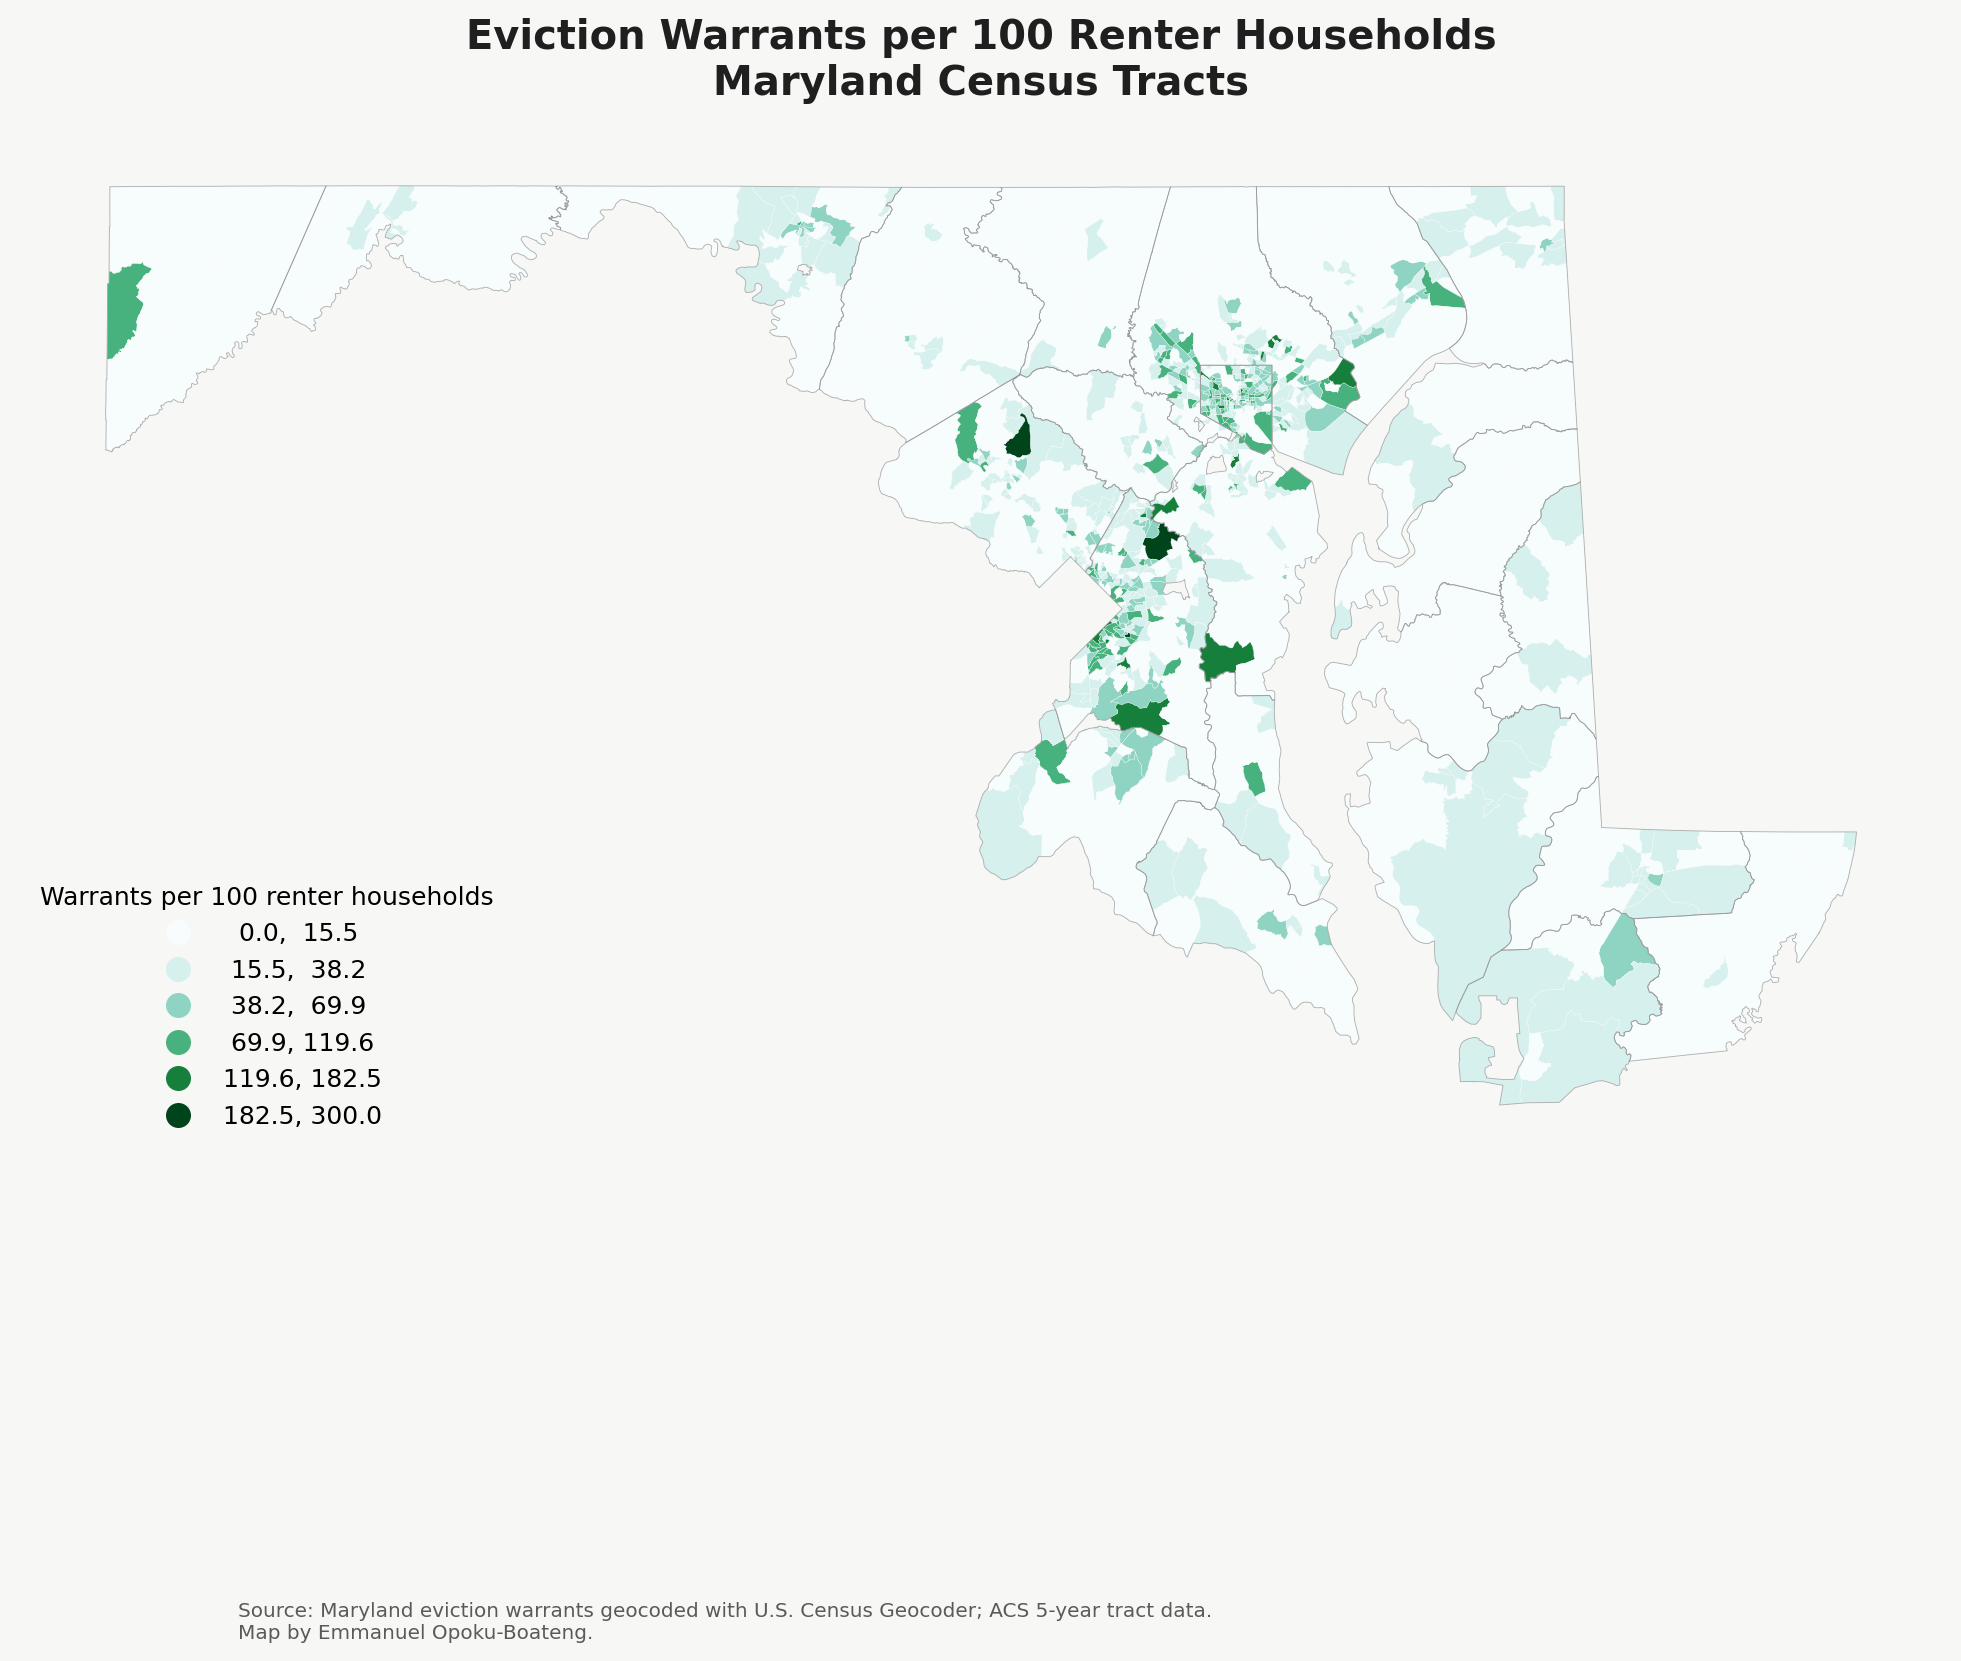

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Create a copy and drop rows with no mapped value
map_df = tract_summary.dropna(subset=['warrants_per_100_renter_hh']).copy()

# Create county outlines for context if COUNTYFP exists
county_outline = None
if 'COUNTYFP' in map_df.columns:
    county_outline = map_df.dissolve(by='COUNTYFP')

# Identify a few highest-rate tracts to label
top_n = 8
label_df = map_df.nlargest(top_n, 'warrants_per_100_renter_hh').copy()
label_points = label_df.representative_point()

fig, ax = plt.subplots(figsize=(11, 12), dpi=180)
fig.patch.set_facecolor('#f7f7f5')
ax.set_facecolor('#f7f7f5')

# Main choropleth
map_df.plot(
    column='warrants_per_100_renter_hh',
    scheme='NaturalBreaks',     #
    k=6,                        
    cmap='BuGn',              
    linewidth=0.12,
    edgecolor='#ffffff',
    legend=True,
    ax=ax,
    missing_kwds={
        'color': '#e5e3df',
        'edgecolor': '#ffffff',
        'label': 'No data'
    },
    legend_kwds={
        'title': 'Warrants per 100 renter households',
        'loc': 'lower left',
        'frameon': False,
        'fmt': '{:.1f}'
    }
)

# County outlines for structure
if county_outline is not None:
    county_outline.boundary.plot(
        ax=ax,
        color='#8f8f8f',
        linewidth=0.35,
        alpha=0.7
    )


# Title 
ax.set_title(
    'Eviction Warrants per 100 Renter Households\nMaryland Census Tracts',
    loc='center',
    fontsize=16,
    fontweight='bold',
    color='#1f1f1f',
    pad=18
)

# Source 
fig.text(
    0.125, 0.04,
    'Source: Maryland eviction warrants geocoded with U.S. Census Geocoder; ACS 5-year tract data.\nMap by Emmanuel Opoku-Boateng.',
    ha='left',
    fontsize=8,
    color='#5a5a5a'
)

# Remove axes and tighten layout
ax.axis('off')
plt.tight_layout()
plt.show()

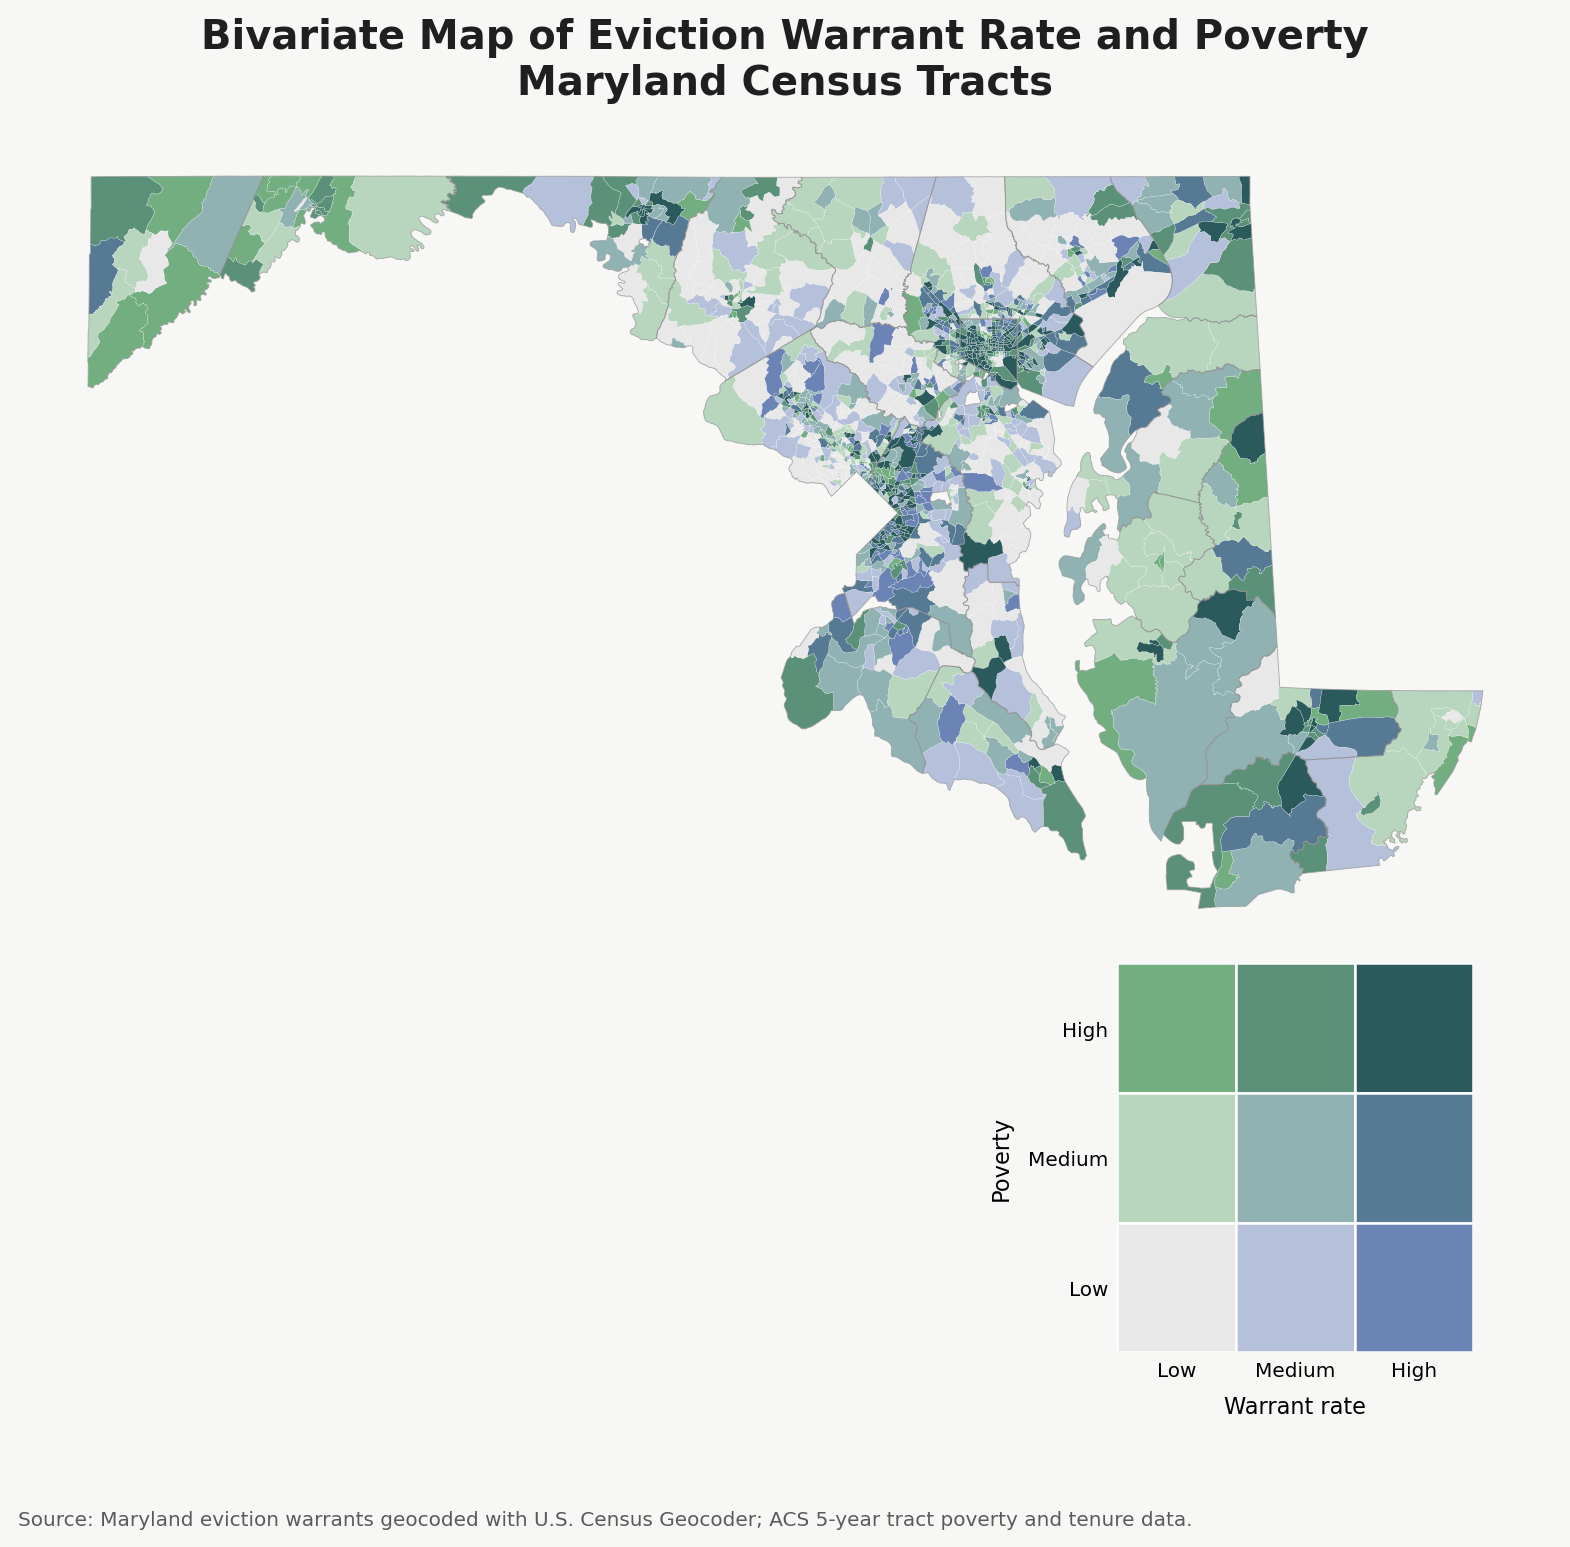

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pandas as pd

# 1. Create bivariate classes
biv = tract_summary.copy()

# Keep only rows with both variables
biv = biv.dropna(subset=['warrants_per_100_renter_hh', 'pct_poverty']).copy()

# Create 3 quantile classes for each variable
biv['warrant_q'] = pd.qcut(
    biv['warrants_per_100_renter_hh'],
    q=3,
    labels=[1, 2, 3]
).astype(int)

biv['poverty_q'] = pd.qcut(
    biv['pct_poverty'],
    q=3,
    labels=[1, 2, 3]
).astype(int)

# Combine classes into a bivariate code
biv['bivar_class'] = biv['warrant_q'].astype(str) + '-' + biv['poverty_q'].astype(str)

# 2. Define bivariate color mapping
bivar_colors = {
    '1-1': '#e8e8e8',
    '2-1': '#b5c0da',
    '3-1': '#6c83b5',
    '1-2': '#b8d6be',
    '2-2': '#90b2b3',
    '3-2': '#567994',
    '1-3': '#73ae80',
    '2-3': '#5a9178',
    '3-3': '#2a5a5b'
}

biv['color'] = biv['bivar_class'].map(bivar_colors)

# 3. Plot map
fig, ax = plt.subplots(figsize=(11, 12), dpi=180)
fig.patch.set_facecolor('#f7f7f5')
ax.set_facecolor('#f7f7f5')

biv.plot(
    color=biv['color'],
    linewidth=0.08,
    edgecolor='white',
    ax=ax
)

# Add county outlines for structure
if 'COUNTYFP' in biv.columns:
    biv.dissolve(by='COUNTYFP').boundary.plot(
        ax=ax,
        color='#8a8a8a',
        linewidth=0.35,
        alpha=0.7
    )

ax.set_title(
    'Bivariate Map of Eviction Warrant Rate and Poverty\nMaryland Census Tracts',
    loc='center',
    fontsize=16,
    fontweight='bold',
    color='#1f1f1f',
    pad=18
)

ax.axis('off')

# 4. Add bivariate legend
legend_ax = fig.add_axes([0.68, 0.12, 0.18, 0.18])  # [left, bottom, width, height]
legend_ax.set_xlim(0, 3)
legend_ax.set_ylim(0, 3)

grid_order = [
    ['1-3', '2-3', '3-3'],
    ['1-2', '2-2', '3-2'],
    ['1-1', '2-1', '3-1']
]

for i in range(3):
    for j in range(3):
        cls = grid_order[i][j]
        legend_ax.add_patch(
            Rectangle((j, 2 - i), 1, 1, facecolor=bivar_colors[cls], edgecolor='white')
        )

legend_ax.set_xticks([0.5, 1.5, 2.5])
legend_ax.set_xticklabels(['Low', 'Medium', 'High'], fontsize=8)
legend_ax.set_yticks([0.5, 1.5, 2.5])
legend_ax.set_yticklabels(['Low', 'Medium', 'High'], fontsize=8)
legend_ax.set_xlabel('Warrant rate', fontsize=9, labelpad=6)
legend_ax.set_ylabel('Poverty', fontsize=9, labelpad=6)
legend_ax.tick_params(length=0)
for spine in legend_ax.spines.values():
    spine.set_visible(False)

# Source note
fig.text(
    0.125, 0.04,
    'Source: Maryland eviction warrants geocoded with U.S. Census Geocoder; ACS 5-year tract poverty and tenure data.',
    ha='left',
    fontsize=8,
    color='#5a5a5a'
)

plt.show()

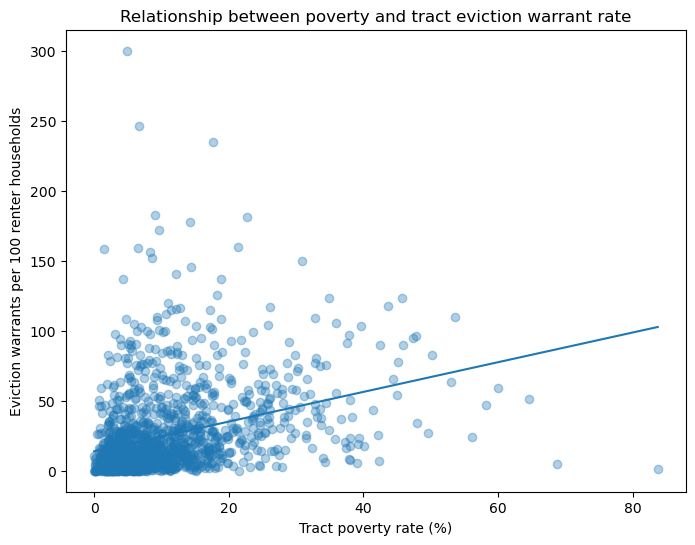

In [ ]:
# Scatter plot of poverty rate vs. warrant rate with a best-fit line    
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(valid['pct_poverty'], valid['warrants_per_100_renter_hh'], alpha=0.35)

# Calculate and plot best-fit line
m, b = np.polyfit(valid['pct_poverty'], valid['warrants_per_100_renter_hh'], 1)
xs = np.linspace(valid['pct_poverty'].min(), valid['pct_poverty'].max(), 100)
ax.plot(xs, m * xs + b)

# Add labels and title
ax.set_xlabel('Tract poverty rate (%)')
ax.set_ylabel('Eviction warrants per 100 renter households')
ax.set_title('Relationship between poverty and tract eviction warrant rate')
plt.show()


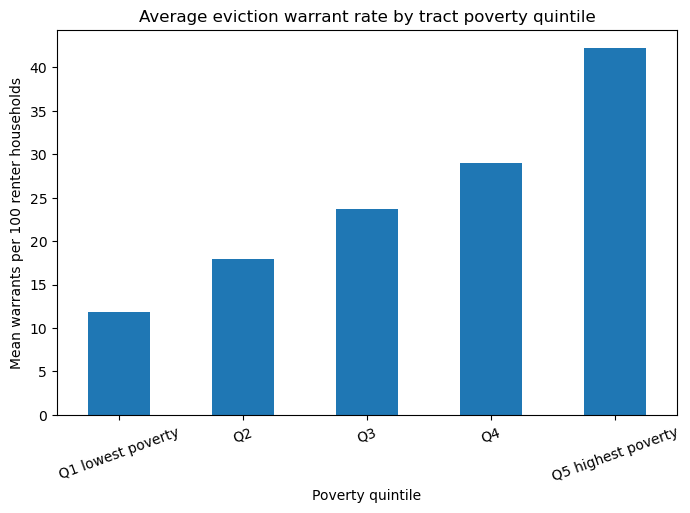

In [ ]:
# Bar chart of average warrant rate by poverty quintile
fig, ax = plt.subplots(figsize=(8, 5))
quintile_summary['mean_warrant_rate'].plot(kind='bar', ax=ax)
ax.set_ylabel('Mean warrants per 100 renter households')
ax.set_xlabel('Poverty quintile')
ax.set_title('Average eviction warrant rate by tract poverty quintile')
plt.xticks(rotation=20)
plt.show()



## 9. Export tract-level results

In [ ]:
# Save outputs
tract_summary.to_parquet('maryland_eviction_tract_summary.geoparquet')
tract_summary.drop(columns='geometry').to_csv('maryland_eviction_tract_summary.csv', index=False)
print('Saved tract-level outputs.')



## Bonus: Is the geocoding quality biased?

I define a **high-quality geocode** as a record with a non-null point and `match_type == 'Exact'`. I define all other records as lower-quality or unmatched. The goal is to test whether exact geocoding appears evenly distributed across the dataset or varies by time and geography.


In [ ]:

# 
bonus_df = warrants_gdf.copy()
bonus_df['exact_geocode'] = bonus_df['match_lon_lat'].notna() & bonus_df['match_type'].eq('Exact')
bonus_df['year'] = bonus_df['EventDate'].dt.year
bonus_df['zip_missing'] = bonus_df['TenantZipCode'].isna()

geo_candidates = [
    'County', 'CountyName', 'FileCounty', 'CourtCounty', 'TenantCounty',
    'PropertyCounty', 'County/City', 'Jurisdiction'
]
geo_field = next((c for c in geo_candidates if c in bonus_df.columns), 'TenantCity')
print(f'Using {geo_field} for the geography comparison.')

exact_by_year = bonus_df.groupby('year')['exact_geocode'].agg(['mean', 'size'])
exact_by_year['mean'] = 100 * exact_by_year['mean']
exact_by_year = exact_by_year.rename(columns={'mean': 'exact_match_pct', 'size': 'n_records'})
exact_by_year


Using County for the geography comparison.


,exact_match_pct,n_records
year,,
2022,50.381679,524
2023,54.838971,160189
2024,54.314991,250325


In [29]:

# Show the places with the highest and lowest exact geocode rates
geo_quality = bonus_df.groupby(geo_field)['exact_geocode'].agg(['mean', 'size']).reset_index()
geo_quality['exact_match_pct'] = 100 * geo_quality['mean']
geo_quality = geo_quality.drop(columns='mean').rename(columns={'size': 'n_records'})

# Keep reasonably sized groups so tiny places do not dominate the extremes
geo_quality_filtered = geo_quality[geo_quality['n_records'] >= 50].copy()

lowest_geo = geo_quality_filtered.sort_values('exact_match_pct').head(15)
highest_geo = geo_quality_filtered.sort_values('exact_match_pct', ascending=False).head(15)

print('Lowest exact geocode rates')
display(lowest_geo)
print('Highest exact geocode rates')
display(highest_geo)


Lowest exact geocode rates


,County,n_records,exact_match_pct
23,Worcester,394,48.730964
14,Kent,170,49.411765
7,Cecil,3743,51.375902
0,Allegany,879,51.763367
16,Prince George's,67003,52.161843
20,Talbot,218,53.211009
9,Dorchester,1237,53.435732
8,Charles,5518,53.533889
15,Montgomery,29074,53.594277
12,Harford,11973,54.405746


Highest exact geocode rates


,County,n_records,exact_match_pct
11,Garrett,124,67.741935
5,Caroline,393,59.796438
18,Saint Mary's,2207,58.495696
17,Queen Anne's,246,58.130081
3,Baltimore City,71672,56.669271
19,Somerset,921,56.568947
6,Carroll,1046,56.022945
22,Wicomico,5369,55.969454
21,Washington,6753,55.797423
13,Howard,12589,55.683533


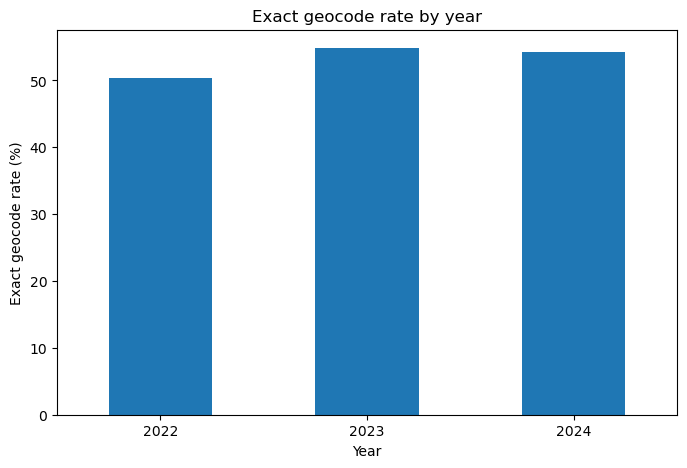

In [30]:

fig, ax = plt.subplots(figsize=(8, 5))
exact_by_year['exact_match_pct'].plot(kind='bar', ax=ax)
ax.set_ylabel('Exact geocode rate (%)')
ax.set_xlabel('Year')
ax.set_title('Exact geocode rate by year')
plt.xticks(rotation=0)
plt.show()


In [32]:

bonus_takeaway = f"""
High-quality geocodes were defined as records with non-null coordinates and an Exact match type. 
Across all warrant records, the exact geocode rate was {100 * bonus_df['exact_geocode'].mean():.1f}%. 
By year, exact-match rates ranged from {exact_by_year['exact_match_pct'].min():.1f}% to {exact_by_year['exact_match_pct'].max():.1f}%. 
Using {geo_field} as the comparison geography, the spread between lower- and higher-performing places suggests that geocoding quality was not perfectly random across the dataset. 
That means any final spatial analysis may slightly underrepresent places or record types with weaker address quality, so reported patterns should be interpreted as conservative estimates of the true geography of eviction.
"""
print(bonus_takeaway)



High-quality geocodes were defined as records with non-null coordinates and an Exact match type. 
Across all warrant records, the exact geocode rate was 54.5%. 
By year, exact-match rates ranged from 50.4% to 54.8%. 
Using County as the comparison geography, the spread between lower- and higher-performing places suggests that geocoding quality was not perfectly random across the dataset. 
That means any final spatial analysis may slightly underrepresent places or record types with weaker address quality, so reported patterns should be interpreted as conservative estimates of the true geography of eviction.

